# Can We augment XGBoost with GNN Embeddings?

In [2]:
import torch
from torch_geometric.datasets import Amazon
import torch_geometric.transforms as T
from torch_geometric.utils import homophily

## Dataset

https://pytorch-geometric.readthedocs.io/en/2.5.3/generated/torch_geometric.datasets.Amazon.html

In [80]:
dataset = Amazon(root='temp/Amazon', name='Computers')
data = dataset[0]

## Graph Stats

### Structural Profiling

In [11]:
print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.num_edges}")
print(f"Features: {data.num_node_features}")
print(f"Classes: {dataset.num_classes}")
print(f"Avg node degree {data.num_edges / data.num_nodes}")

Nodes: 13752
Edges: 491722
Features: 767
Classes: 10
Avg node degree 35.7563990692263


In [5]:
# Homophily
h_ratio = homophily(data.edge_index, data.y, method='edge')
print(f"Edge Homophily Ratio: {h_ratio:.4f}")

Edge Homophily Ratio: 0.7772


In [6]:
# Class Imbalance

counts = torch.unique(data.y, return_counts=True)
print(f"Class distribution: {counts[1].tolist()}")

Class distribution: [436, 2142, 1414, 542, 5158, 308, 487, 818, 2156, 291]


### Data Samples

In [7]:
import pandas as pd

In [9]:
# Node samples
node_idx = 12
sample_features = data.x[node_idx][:10]
sample_label = data.y[node_idx].item()

print(f"\n--- Node {node_idx} Sample ---")
print(f"Label: {sample_label}")
print(f"Feature Slice (first 10): {sample_features}")

# Local Neighborhoods

neighbors = data.edge_index[1, data.edge_index[0] == node_idx]
print(f"node {node_idx} has {neighbors.size(0)} neighbors")
print(f"Example neighbor indices: {neighbors[:5].tolist()}")

# Do neighbors share the same labels
neighbor_labels = data.y[neighbors]
print(f"Neighbor labels: {neighbor_labels[:10].tolist()}")


--- Node 12 Sample ---
Label: 4
Feature Slice (first 10): tensor([1., 1., 0., 0., 1., 0., 1., 1., 1., 0.])
node 12 has 76 neighbors
Example neighbor indices: [95, 114, 153, 218, 294]
Neighbor labels: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


### Quick Intepretation of Results

-High Homophily (0.77) - 77% of all edges connect 2 nodes that share the same label

-Avg Degree (35) - dense neighberhood, good for message passing

-Class Distribution - Severe class imbalance, imbalance ratio ~18 (this needs to be addressed during modeling and for picking a success metric)


## Baseline Model

Let's start with a model to establish a baseline. XGBoost is good at drawing non-linear decision boundaries, and we'll do so using node features only (the 767 dim embedding) 

In [13]:
from xgboost import XGBClassifier
#Let's select macro f1 to treat all classes equally
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import mlflow

In [48]:
mlflow.set_experiment("Amazon Computers Recommender")


random_state = 42
X = data.x.cpu().numpy()
y = data.y.cpu().numpy()

#Strat split to deal with class imbalance

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)


#Init XGBoost


with mlflow.start_run(run_name="XGBoost_Pure_Tabular_Baseline"):
    params = {
        "n_estimators": 100,
        "max_depth": 6,
        "learning_rate": 0.1,
        "tree_method": 'hist',
        "device": 'cuda',
        "objective": 'multi:softprob'
    }

    mlflow.log_params(params)
    
    xgb_baseline = XGBClassifier(**params, random_state=random_state)
    xgb_baseline.fit(X_train, y_train)

    preds = xgb_baseline.predict(X_test)
    macro_f1 = f1_score(y_test, preds, average='macro')
    report = classification_report(y_test, preds, output_dict=True)

    mlflow.log_metric("test_macro_f1", macro_f1)

    mlflow.xgboost.log_model(xgb_baseline, "model")
    

print(f"Baseline XGboost Macro f1 {macro_f1}")
print('--------------------')

print(classification_report(y_test, preds))

2026/05/13 20:37:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Baseline XGboost Macro f1 0.8243523373466577
--------------------
              precision    recall  f1-score   support

           0       0.88      0.60      0.71        87
           1       0.91      0.87      0.89       429
           2       0.87      0.95      0.91       283
           3       0.94      0.93      0.93       108
           4       0.90      0.92      0.91      1032
           5       0.92      0.94      0.93        62
           6       0.65      0.27      0.38        97
           7       0.92      0.90      0.91       164
           8       0.75      0.86      0.80       431
           9       0.89      0.84      0.87        58

    accuracy                           0.87      2751
   macro avg       0.86      0.81      0.82      2751
weighted avg       0.87      0.87      0.87      2751



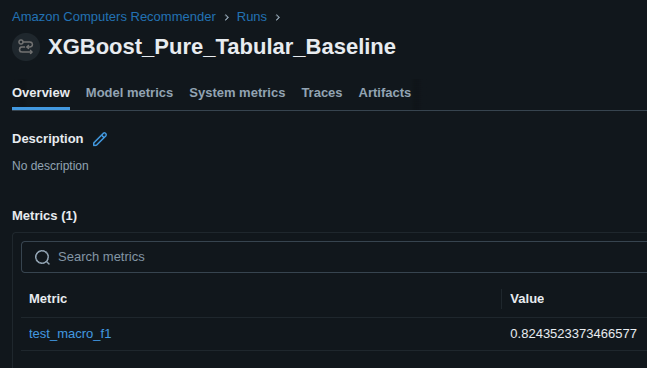
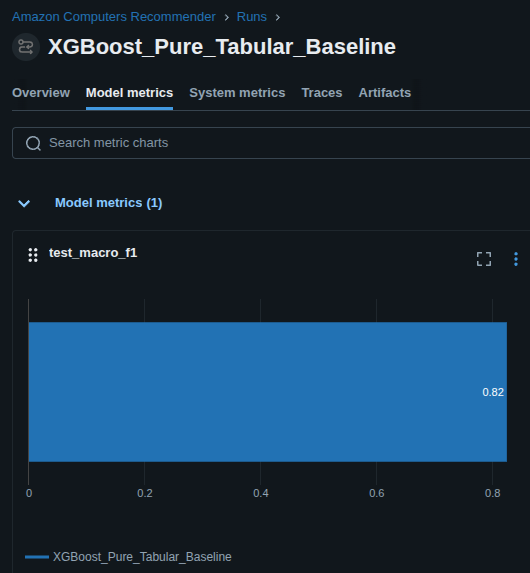

### Results Interpretation and next steps

-Solid baseline (0.82) with just using node features but class 6 has a poor recall (0.27) and f1 score  (0.38)

-XGBoost is leveraging node features independentaly and not taking in consideration the structural context provided by the graph

-Given the high homophily and xgboost nature, we will leverage GNNs for their message passing power to improve our success metric. For nodes labeled with class 6 in particular, the GNN will help these nodes borrow information from their neighboors

-To this end, we won't discard the XGBoost since the baseline is solid but we'll use a GNN as an automated feature engineering engine or a toplogical feature extractor that will use neighboring nodes info to maximize understanding of recommendation

-It's tempting to just throw a GCN at this problem as seen in the literature (https://kumo.ai/pyg/datasets/amazon-computers/) but the GCN will just average node info and propagate it since it uses a fixed mean aggregrator which won't solve our class 6 issue, especially with the high average node degree

-Let's start with a vanilla GraphSage so we can control the aggregator a bit better than a mean agg from a GCN

In [20]:
from torch_geometric.nn import SAGEConv
import torch.nn.functional as F

In [21]:
class VanillaGraphSage(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()

        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):

        #Let's start with mean aggregators and see the impact

        #layer1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)

        #layer2
        x = self.conv2(x, edge_index)

        return x

Since PyG doesn't natively with Stratification let's create a function for the split

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:
def create_stratified_masks(data):
    num_nodes = data.num_nodes
    indices = np.arange(num_nodes)
    
    
    y = data.y.cpu().numpy() 
    
    train_idx, rest_idx = train_test_split(indices, test_size=0.3, stratify=y, random_state=42)
    
    
    val_idx, test_idx = train_test_split(rest_idx, test_size=2/3, stratify=y[rest_idx], random_state=42)
    
    train_mask = torch.zeros(num_nodes, dtype=torch.bool, device=data.x.device)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool, device=data.x.device)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool, device=data.x.device)
    
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    
    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask
    
    return data




In [39]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

In [40]:
set_seed(42)
data = create_stratified_masks(data)
data = data.to(device)

In [41]:
print(f"Data is on: {data.x.device}")
print(f"Model is on: {next(model.parameters()).device}")

Data is on: cuda:0
Model is on: cuda:0


In [42]:
import mlflow.pytorch

# config
params = {
    "model_type": "VanillaGraphSage_Baseline",
    "hidden_channels": 128,
    "output_channels": 10,
    "lr": 0.01,
    "epochs": 200,
    "dropout": 0.5
}


with mlflow.start_run(run_name="Vanilla GraphSage"):
    mlflow.log_params(params)

    # init model
    model = VanillaGraphSage(data.num_features, params["hidden_channels"], params["output_channels"]).to(device)

    # set optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
    
    # training
    for epoch in range(params["epochs"]):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask] , data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
           
            model.eval()
            with torch.no_grad():
                val_logits = model(data.x, data.edge_index)
                val_preds = val_logits[data.val_mask].argmax(dim=1).cpu().numpy()
                val_y = data.y[data.val_mask].cpu().numpy()
                val_macro = f1_score(val_y, val_preds, average="macro")
                
                mlflow.log_metric("train_loss", loss.item(), step=epoch)
                mlflow.log_metric("val_macro_f1", val_macro, step=epoch)

    # eval
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        preds = logits[data.test_mask].argmax(dim=1).cpu().numpy()
        y_true = data.y[data.test_mask].cpu().numpy()

    # metrics
    report = classification_report(y_true, preds, output_dict=True)
    macro_f1 = f1_score(y_true, preds, average="macro")

    # logging
    mlflow.log_metric("test_macro_f1", macro_f1)
    mlflow.log_metric("class_6_f1", report['6']['f1-score'])
    mlflow.log_metric("class_6_recall", report['6']['recall'])

    # save model artifact
    mlflow.pytorch.log_model(model, "model")

    print(f"--- Vanilla GraphSage Baseline Results ---")
    print(f"Macro F1: {macro_f1}")
    print(f"Class 6 F1 Score: {report['6']['f1-score']}")
    print(classification_report(y_true, preds))

2026/05/13 19:25:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 19:25:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/13 19:25:48 WARNING mlflow.utils.requirements_utils: Found pyg-lib version (0.4.0+pt25cu121) contains a local version label (+pt25cu121). MLflow logged a pip requirement for this package as 'pyg-lib==0.4.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/13 19:25:48 WARNING mlflow.utils.requirements_utils: Found torch-cluster version (1.6.3+pt25cu121) contains 

--- Vanilla GraphSage Baseline Results ---
Macro F1: 0.7358012804492534
Class 6 F1 Score: 0.36363636363636365
              precision    recall  f1-score   support

           0       0.94      0.75      0.83        87
           1       0.96      0.86      0.91       429
           2       0.91      0.98      0.94       283
           3       0.91      0.72      0.81       109
           4       0.88      0.93      0.90      1032
           5       0.56      0.95      0.71        61
           6       0.92      0.23      0.36        97
           7       0.95      0.88      0.92       163
           8       0.74      0.88      0.81       432
           9       0.50      0.10      0.17        58

    accuracy                           0.86      2751
   macro avg       0.83      0.73      0.74      2751
weighted avg       0.87      0.86      0.85      2751



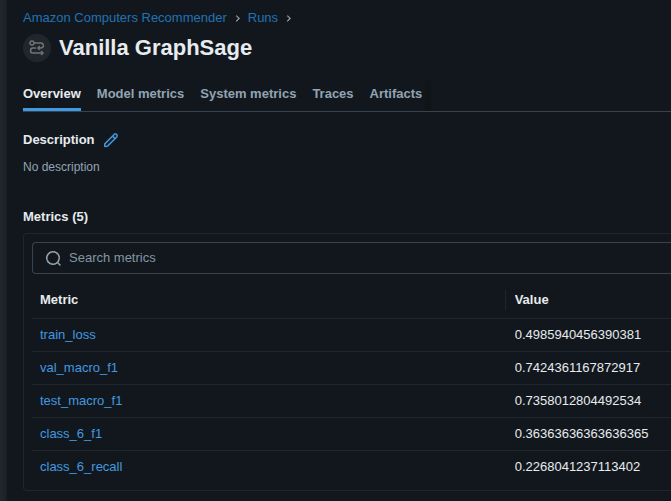
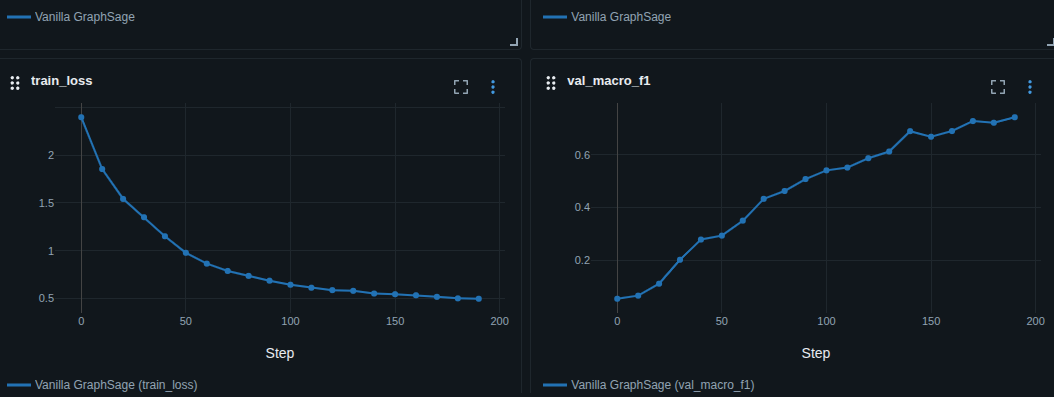

### GraphSAGE Baseline Interpretation and Next Steps

-OK performance with a 2 layer vanilla GraphSAGE (0.73) (but still not as good as XGBoost 0.82 score)

-The macro f1 score of 0.73 points to proper & unbiased learning using topology features 

-Still poor performance on the Class 6 label (0.36 f1 score and 0.23 recall), which validates the concern about the standard mean aggregator on these class 6 nodes

-The fact that the GraphSAGE underperformed XGBoost might mean that it's valuing neighberhood signal over actual node features, so we need to remediate this by forcing the model to keep the node's own features beside the neighborhood average

-We might benefit from a weighted loss function to account for class imbalance, so we'll try weighted cross entropy

## Updating the Model

In [43]:
class RootWeightedGraphSage(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()

        self.conv1 = SAGEConv(in_channels, hidden_channels, root_weight=True)
        self.conv2 = SAGEConv(hidden_channels, out_channels, root_weight=True)

    def forward(self, x, edge_index):

        #layer1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)

        #layer2
        x = self.conv2(x, edge_index)

        return x

In [44]:
# Calculate weights based on class frequency in the training set
train_labels = data.y[data.train_mask].cpu().numpy()
class_counts = np.bincount(train_labels, minlength=10)

# Inverse frequency weighting
weights = 1. / torch.tensor(class_counts, dtype=torch.float)
weights = weights / weights.sum() * 10  # Normalize so they sum to num_classes
weights = weights.to(device)

print(f"Class Weights: {weights.tolist()}")

Class Weights: [1.4415956735610962, 0.29332002997398376, 0.44412797689437866, 1.1601232290267944, 0.1217968687415123, 2.0355865955352783, 1.2894036769866943, 0.7673415541648865, 0.2913762331008911, 2.155327081680298]


In [45]:
# Double-check device placement
weights = weights.to(device)

In [47]:
params = {
    "model_type": "RootSAGE_WeightedLoss",
    "hidden_channels": 128,
    "output_channels": 10,
    "lr": 0.005, #lowering lr a bit
    "epochs": 200,
    "weighted_loss": True,
    "root_weight": True
}

with mlflow.start_run(run_name="RootSAGE_Weighted"):
    mlflow.log_params(params)
    model = RootWeightedGraphSage(data.num_features, params["hidden_channels"], 10).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
    
    for epoch in range(params["epochs"]):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        
        #apply the new weights here
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask], weight=weights)
        
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                val_logits = model(data.x, data.edge_index)
                val_preds = val_logits[data.val_mask].argmax(dim=1).cpu().numpy()
                val_macro = f1_score(data.y[data.val_mask].cpu(), val_preds, average="macro")
                mlflow.log_metrics({"train_loss": loss.item(), "val_macro_f1": val_macro}, step=epoch)

    # eval
    model.eval()
    with torch.no_grad():
        test_logits = model(data.x, data.edge_index)
        preds = test_logits[data.test_mask].argmax(dim=1).cpu().numpy()
        y_true = data.y[data.test_mask].cpu().numpy()


    # metrics
    report = classification_report(y_true, preds, output_dict=True)
    macro_f1 = f1_score(y_true, preds, average="macro")
    
    mlflow.log_metrics({
        "test_macro_f1": f1_score(y_true, preds, average="macro"),
        "class_6_f1": report['6']['f1-score'],
        "class_6_recall": report['6']['recall']
    })

    # logging
    mlflow.log_metric("test_macro_f1", macro_f1)
    mlflow.log_metric("class_6_f1", report['6']['f1-score'])
    mlflow.log_metric("class_6_recall", report['6']['recall'])

    # save model artifact
    mlflow.pytorch.log_model(model, "model")

    print(f"--- Root Weighted GraphSage Results ---")
    print(f"Macro F1: {macro_f1}")
    print(f"Class 6 F1 Score: {report['6']['f1-score']}")
    print(classification_report(y_true, preds))

2026/05/13 19:53:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 19:53:25 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/13 19:53:29 WARNING mlflow.utils.requirements_utils: Found pyg-lib version (0.4.0+pt25cu121) contains a local version label (+pt25cu121). MLflow logged a pip requirement for this package as 'pyg-lib==0.4.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/13 19:53:29 WARNING mlflow.utils.requirements_utils: Found torch-cluster version (1.6.3+pt25cu121) contains 

--- Root Weighted GraphSage Results ---
Macro F1: 0.891294310090964
Class 6 F1 Score: 0.712
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        87
           1       0.91      0.94      0.92       429
           2       0.94      0.98      0.96       283
           3       0.87      0.95      0.91       109
           4       0.94      0.90      0.92      1032
           5       0.97      0.95      0.96        61
           6       0.58      0.92      0.71        97
           7       0.93      0.94      0.93       163
           8       0.85      0.76      0.80       432
           9       0.88      0.90      0.89        58

    accuracy                           0.90      2751
   macro avg       0.88      0.91      0.89      2751
weighted avg       0.90      0.90      0.90      2751



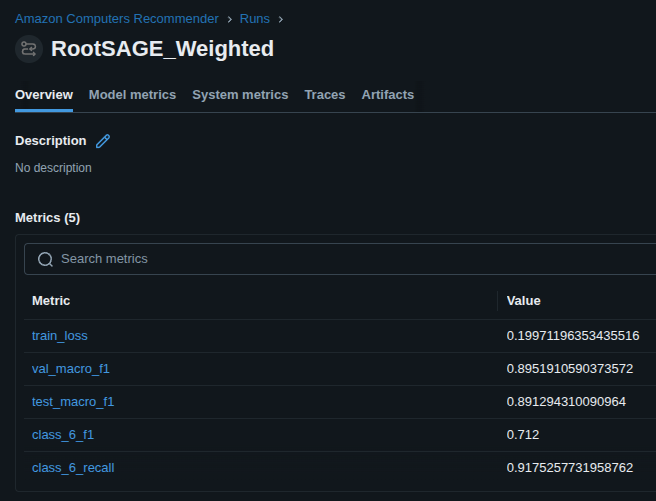
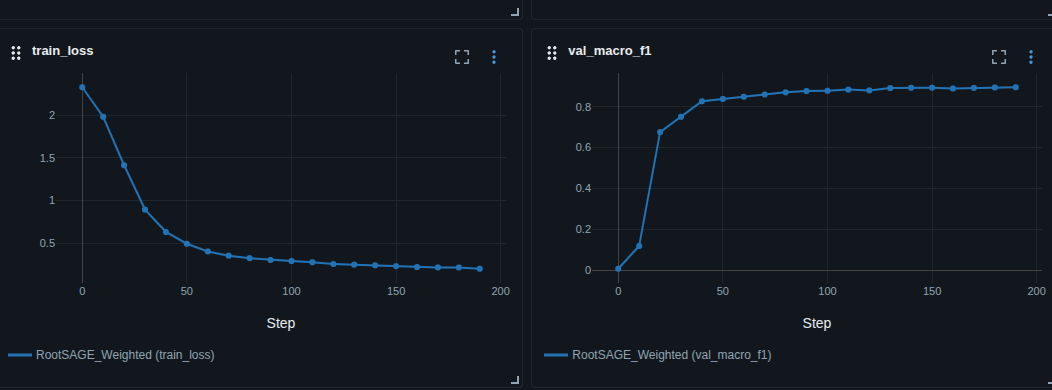

## Results Interpretation and Next Steps

-Drastic improvement in the overall test macro f1 score from 0.73 to 0.89. This was likely the result of using the node's own features (through root=True) beside the neighborhood information. The weighted loss might also have punished imbalanced, thus better learning from all classes equally

-We can also notice a massive improvement in the Class 6 metrics (recall from 0.23 to 0.92), using the node's own features might have helped these nodes by not being dominated by neighboring nodes with a higher and different label

-The GNN proved to be a solid feature extracture and we can feed its embeddings to XGBoost instead of using the data as is. So for a final dig at this, let's combine both GraphSAGE power of leveraging topology and node's own features with the decision boundaries of XGBoost and see if it could improve overall performance. 

-The idea is simple, we generate topology & node rich embeddings from the optimized GraphSAGE. we concatente them with the raw features then feed the resulting matrix to XGBoost.

In [49]:
model

RootWeightedGraphSage(
  (conv1): SAGEConv(767, 128, aggr=mean)
  (conv2): SAGEConv(128, 10, aggr=mean)
)

In [50]:
model.eval()
with torch.no_grad():

    gnn_embeddings = model(data.x, data.edge_index).cpu().numpy()

    raw_features = data.x.cpu().numpy()

    #raw data + structual context
    
    X_hybrid = np.hstack([raw_features, gnn_embeddings])
    y = data.y.cpu().numpy()

X_train_hyb = X_hybrid[data.train_mask.cpu()]
y_train_hyb = y[data.train_mask.cpu()]

X_test_hyb = X_hybrid[data.test_mask.cpu()]
y_test_hyb = y[data.test_mask.cpu()]

with mlflow.start_run(run_name="Hybrid_RootSage_XGBoost"):
    params = {
        "n_estimators": 100,
        "max_depth": 6,
        "learning_rate": 0.1,
        "tree_method": 'hist',
        "device": 'cuda',
        "objective": 'multi:softprob',
        "random_state": 42
    }

    mlflow.log_params(params)
    mlflow.log_param("approach", "GNN_Embedding_Augmentation")

    # init and train xgboost on hybrid features
    xgb_hybrid = XGBClassifier(**params)
    xgb_hybrid.fit(X_train_hyb, y_train_hyb)

    #eval

    preds = xgb_hybrid.predict(X_test_hyb)
    macro_f1 = f1_score(y_test_hyb, preds, average="macro")
    report = classification_report(y_test_hyb, preds, output_dict=True)

    #log metrics
    mlflow.log_metric("test_macro_f1", macro_f1)
    mlflow.log_metric("class_6_f1", report['6']['f1-score'])
    mlflow.log_metric("class_6_precision", report['6']['precision'])
    mlflow.log_metric("class_6_recall", report['6']['recall'])

    mlflow.xgboost.log_model(xgb_hybrid, "hybrid_model")
    print(f"--- Hybrid GNN XGBoost Results ---")
    print(f"Hybrid Macro F1: {macro_f1}")
    print(f"Class 6 F1 Score: {report['6']['f1-score']}")
    print("\nFull Classification Report:\n")
    print(classification_report(y_test_hyb, preds))

2026/05/13 21:03:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- Hybrid GNN XGBoost Results ---
Hybrid Macro F1: 0.9057975386177693
Class 6 F1 Score: 0.7936507936507936

Full Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.89      0.91        87
           1       0.94      0.92      0.93       429
           2       0.95      0.99      0.97       283
           3       0.94      0.94      0.94       109
           4       0.92      0.94      0.93      1032
           5       0.97      0.93      0.95        61
           6       0.82      0.77      0.79        97
           7       0.95      0.94      0.94       163
           8       0.85      0.84      0.85       432
           9       0.86      0.84      0.85        58

    accuracy                           0.91      2751
   macro avg       0.91      0.90      0.91      2751
weighted avg       0.91      0.91      0.91      2751



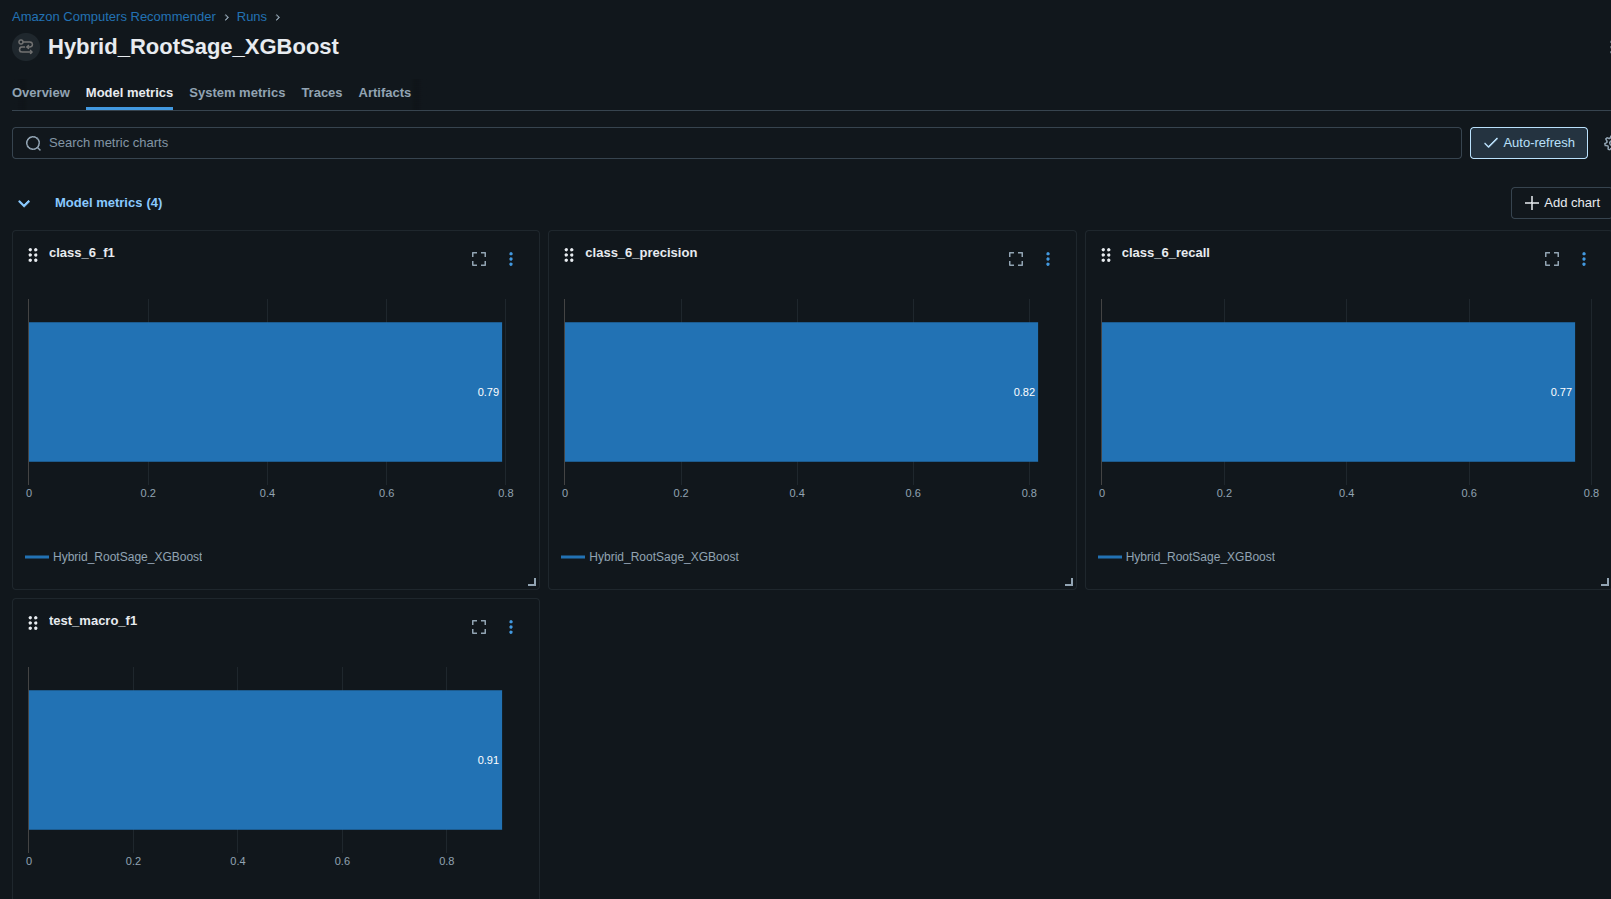

In [94]:
import torch
import gc

# 1. Delete the massive tensors/models
del model

# 2. Force Python Garbage Collection
gc.collect()

# 3. Clear NVIDIA VRAM
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print("System RAM and VRAM cleared.")

System RAM and VRAM cleared.
